# Free-Running Frequency Offset: Observation and Compensation

When two SDRs are **not** locked to a shared reference clock, each one runs on its own free-running local oscillator (LO). Even two "identical" oscillators differ by a few parts-per-million, so the transmitter's carrier and the receiver's carrier are never at *exactly* the same frequency — this mismatch is the **carrier frequency offset (CFO)**.

In this lab you transmit a single, unmodulated symbol from one Pluto SDR and capture it on a second, independent Pluto SDR. The transmitted symbol carries no information of its own — it is just one fixed point in the IQ plane — so **any motion you see at the receiver comes entirely from the CFO** between the two free-running LOs.

You will:
1. **Observe** the CFO as a rotating phasor in the IQ plane.
2. **Estimate** the offset directly from the received samples — this part you write yourself.
3. **Compensate** for it and confirm the corrected signal is stationary.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import scipy
import adi

## Hardware Configuration

In [2]:
fs = int(2.0e6)           # Sample rate: 2.0 MHz
fc = int(900e6)               # RF carrier (Hz) -- pick a valid Pluto carrier frequency,
                            # e.g. somewhere in the ISM band around 915e6

# Connect to the two independent Pluto SDRs
tx_sdr = adi.Pluto("ip:192.168.2.1")
rx_sdr = adi.Pluto("ip:192.168.3.1")

#################################################
# Config TX
tx_sdr.sample_rate = fs
tx_sdr.tx_lo = fc
tx_sdr.tx_rf_bandwidth = fs
tx_sdr.tx_hardwaregain_chan0 = -4 # dB, valid range -90 to 0
tx_sdr.tx_cyclic_buffer = True      # loop the transmission indefinitely

##########################################
# Config RX
rx_sdr.sample_rate = fs
rx_sdr.rx_lo = fc
rx_sdr.rx_rf_bandwidth = fs
rx_sdr.rx_buffer_size = 100000
rx_sdr.gain_control_mode_chan0 = "manual"
rx_sdr.rx_hardwaregain_chan0 = 30   # dB, fixed gain avoids AGC-induced fluctuations

## Task 1: Generate and Transmit a Constant Symbol

Build a TX buffer that is the **same complex number repeated** `tx_length` times — a single, unmoving point at $(1, 1)$ in the IQ plane, scaled to fit the Pluto's 16-bit DAC. Because it carries no waveform of its own, whatever the receiver sees riding on top of it has to come from the hardware, not the signal.

In [3]:
# Parameters
tx_length = 4096 * 2   # number of samples in the TX buffer
tx_scale = 2**14     # DAC full-scale headroom

# TODO: Build a constant complex array of length tx_length, equal to (1 + 1j),
#       scaled by tx_scale / np.sqrt(2) so the I and Q peaks stay within DAC range
#       (np.ones() with dtype=np.complex64 is useful here)
tx_signal = np.ones(tx_length, dtype=np.complex64)*(1+1j)*tx_scale/np.sqrt(2)  # assign your constant-symbol array to tx_signal

In [4]:
tx_sdr.tx(tx_signal)
time.sleep(0.5)           # allow the PLLs to lock
# Flush stale samples already sitting in the hardware buffer
for _ in range(5):
    _ = rx_sdr.rx()

rx_samples = rx_sdr.rx()

# Stop the transmitter
'''tx_sdr.tx_destroy_buffer()'''

'tx_sdr.tx_destroy_buffer()'

## Task 2: Observe the Rotating Phasor (IQ Plane)

If the transmitter and receiver carriers were at *exactly* the same frequency, every received sample would land on the same spot. Plot the received samples as points in the IQ plane and see what actually happens.

Revolutions: 5.520487331177881
Phase step: 0.008671561221931978
Estimated frequency: 2760.2436655889405


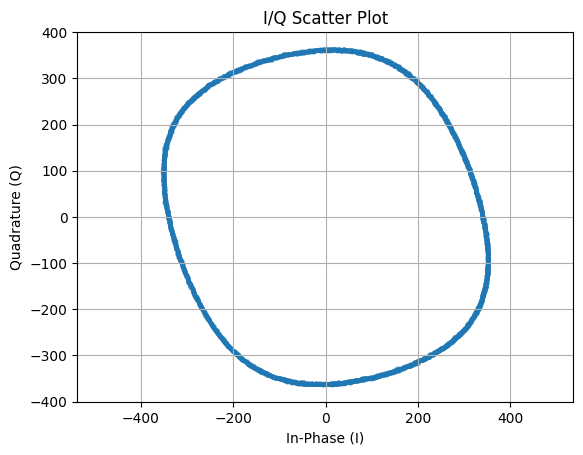

In [5]:
# TODO: Scatter-plot the real part (I) vs. the imaginary part (Q) of
#       rx_samples[1000:5000] -- small markers with some transparency (alpha)
#       make overlapping points easier to see
plt.scatter(
    rx_samples[1000:5000].real,
    rx_samples[1000:5000].imag,
    s=5,
    alpha=0.5
)
angles = np.angle(rx_samples[1000:5000])
unwrapped = np.unwrap(angles)
revolutions = (unwrapped[-1]-unwrapped[0])/(2*np.pi)
print("Revolutions:",revolutions)
phase_step = revolutions*2*np.pi/4000
print("Phase step:",phase_step)
print("Estimated frequency:",fs*phase_step/(2*np.pi))
# TODO: Label the axes 'In-Phase (I)' and 'Quadrature (Q)', and add a title and grid
plt.xlabel('In-Phase (I)')
plt.ylabel('Quadrature (Q)')
plt.title('I/Q Scatter Plot')
plt.grid(True)
# TODO: Call plt.axis('equal') so the circle isn't stretched out of shape
plt.axis('equal')
plt.show()

## Task 3: Watch the Phase Unwind Over Time

The IQ scatter plot shows *where* the phasor goes, but not *how fast*. Plotting the phase of each sample against its position in the buffer shows the same offset from a different angle — literally.

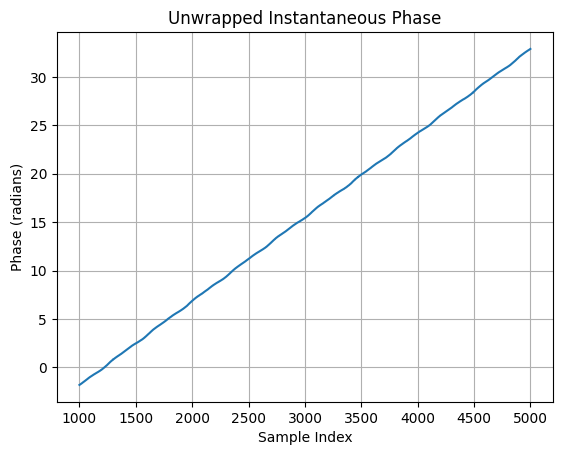

In [6]:
# TODO: Compute the instantaneous phase (in radians) of each sample in
#       rx_samples[1000:5000] using np.angle()
phase = np.angle(rx_samples[1000:5000])
# TODO: np.unwrap() the phase so it doesn't jump by +/-2*pi every time it wraps
unwrapped_phase = np.unwrap(phase)
sample_index = np.arange(1000,5000)
# TODO: Plot the unwrapped phase against sample index, with axis labels and a grid.
#       What shape is the curve, and what does its slope represent?
plt.plot(sample_index, unwrapped_phase)
plt.xlabel('Sample Index')
plt.ylabel('Phase (radians)')
plt.title('Unwrapped Instantaneous Phase')
plt.grid(True)
plt.show()

## Task 4: Estimate the Frequency Offset

A constant CFO advances the phase by a fixed amount from one sample to the next:

$$\angle x[n+1] - \angle x[n] \approx 2\pi \, \Delta f \, T_s$$

where $T_s = 1/f_s$. Differencing the *unwrapped* phase from Task 3 works, but it's fragile — one noisy sample near a wrap point throws it off. A more robust way to get the same quantity is the **conjugate-multiply trick**:

$$\Delta\phi[n] = \angle\big(x[n{+}1]\,x^{*}[n]\big)$$

which gives the same per-sample phase step directly, already wrapped into $(-\pi, \pi]$ with no unwrapping required. Averaging $\Delta\phi[n]$ over many samples cancels out noise far better than reading it off any single pair.

**Your task:** using `np.conj`, `np.angle`, and `np.mean` on the *full* `rx_samples` buffer (not just the 4000-sample slice used for plotting), compute a single averaged estimate of the offset, in Hz, and store it in a variable called `f_offset_hat`.

In [7]:
# TODO: Compute the sample-to-sample phase step for the full rx_samples buffer
#       using the conjugate-multiply trick above
phase_steps = np.angle(rx_samples[1:] * np.conj(rx_samples[:-1]))
# TODO: Average the phase steps into a single robust value (np.mean)
mean_phase_step = np.mean(phase_steps)
# TODO: Convert that average phase-per-sample (rad/sample) into a frequency in Hz
#       using fs, and store it as f_offset_hat
f_offset_hat =  mean_phase_step * fs / (2 * np.pi)
# TODO: Print f_offset_hat
print(f_offset_hat)

2761.865483500032


## Task 5 (Cross-Check): Confirm in the Frequency Domain

You already used the PSD peak-location method to find a frequency offset in the sine/square-wave lab. A constant symbol has no waveform of its own, so its spectrum should be one tall spike — wherever that spike sits away from 0 Hz is the same CFO you just measured in Task 4.

Reuse that method here, then compare the two numbers. They won't match exactly — think about why as you answer the Questions section.

Peak frequency: 2760.0 Hz


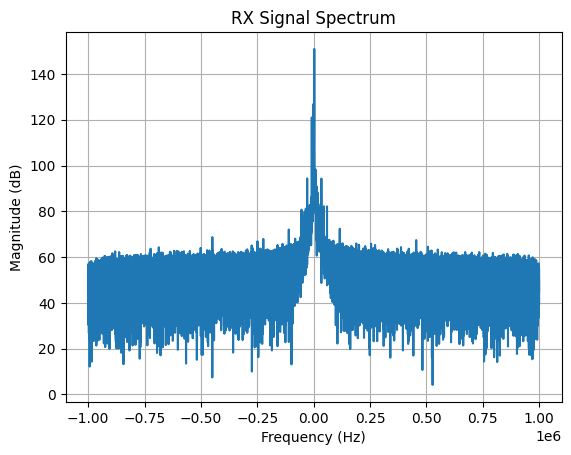

In [8]:
# TODO: Compute the FFT of rx_samples, shift it with np.fft.fftshift, and convert
#       the magnitude to a PSD in dB (as you did earlier for the sine and square waves)
N = len(rx_samples)
rx_fft = np.fft.fft(rx_samples)
rx_fft_shifted = np.fft.fftshift(rx_fft)
psd_db = 20 * np.log10(np.abs(rx_fft_shifted) + 1e-12)
# TODO: Build the matching frequency axis (np.fft.fftfreq + fftshift, or
#       np.linspace over [-fs/2, fs/2])
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/fs))
#d = 1/fs is the reason why we have to trust the phase difference estimate from task 4 more than the estimate from task 5.
# TODO: Find the frequency at the PSD peak (np.argmax) and print it
peak_idx = np.argmax(psd_db)
peak_freq = freqs[peak_idx]
print("Peak frequency:", peak_freq, "Hz")
# TODO: Plot the PSD vs. frequency, with labels, title, and grid
plt.plot(freqs, psd_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("RX Signal Spectrum")
plt.grid(True)
plt.show()

## Task 6: Compensate — Cancel the Offset

Once you have $\Delta \hat f$, you can undo its effect by multiplying every sample with a phasor rotating at exactly $-\Delta \hat f$:

$$y[n] = x[n] \cdot e^{-j 2\pi \Delta \hat f \, n \, T_s}$$

This is the same correction every real receiver's CFO-tracking loop performs continuously — here you do it once, in software, using the estimate from Task 4.

In [9]:
s_idx = np.arange(len(rx_samples))

# TODO: Build the correcting complex exponential using f_offset_hat, n, and fs --
#       mind the minus sign, it needs to rotate opposite to the offset
correction = np.exp(-1j * 2 * np.pi * f_offset_hat * s_idx / fs)
# TODO: Multiply it elementwise with rx_samples and store the result as rx_corrected
rx_corrected = rx_samples * correction

## Task 7: Verify the Compensation

Re-plot the IQ scatter, this time for `rx_corrected`. If your estimate was good, the circle from Task 2 should have collapsed down to a single tight cluster.

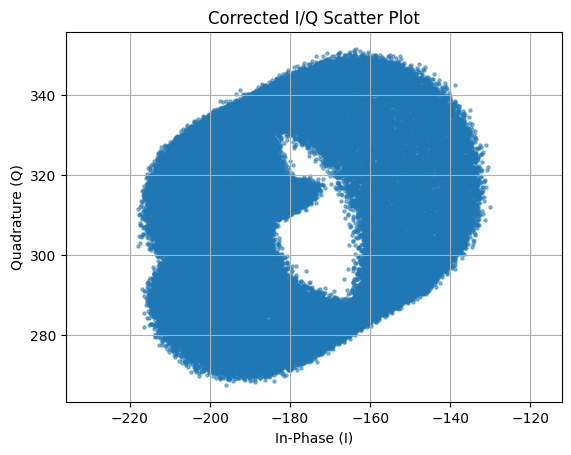

In [10]:
# TODO: Scatter-plot the real vs. imaginary part of rx_corrected[1000:5000], using
#       the same labels, title, grid, and equal-aspect settings as Task 2, so the
#       two plots are directly comparable
plt.scatter(
    rx_corrected[:].real,
    rx_corrected[:].imag,
    s=5,
    alpha=0.5
)

plt.xlabel('In-Phase (I)')
plt.ylabel('Quadrature (Q)')
plt.title('Corrected I/Q Scatter Plot')
plt.grid(True)
plt.axis('equal')
plt.show()
# TODO: If it still looks like a (smaller/slower) circle rather than a point, what
#       would you check first?
# I would check for the accuracy of my CFO compensation. If not accurate, it could lead to circular scatter plots. I would try to find an optimal tx and rx buffer size for CFO
# compensation accuracy and noise effect mitigation.

## Bonus: Is the Offset Really "Free-Running"?

A free-running oscillator isn't perfectly constant — it drifts slowly with temperature and time. Repeat Tasks 1-4 after leaving the hardware untouched for a minute or two, and compare the new `f_offset_hat` with your first one.

In [1]:
#Running tasks 1 to 4 again to observe the different f_offset_hat
tx_sdr.tx(tx_signal)
time.sleep(0.5)
time.sleep(90) #wait for 90 seconds before again estimating f_offset_hat to observe the difference.
for _ in range(5):
    _ = rx_sdr.rx()

rx_samples = rx_sdr.rx()

# Stop the transmitter
'''tx_sdr.tx_destroy_buffer()'''

NameError: name 'tx_sdr' is not defined

In [ ]:
plt.scatter(
    rx_samples[1000:5000].real,
    rx_samples[1000:5000].imag,
    s=5,
    alpha=0.5
)
angles = np.angle(rx_samples[1000:5000])
unwrapped = np.unwrap(angles)
revolutions = (unwrapped[-1]-unwrapped[0])/(2*np.pi)
print("Revolutions:",revolutions)
phase_step = revolutions*2*np.pi/4000
print("Phase step:",phase_step)
print("Estimated frequency:",fs*phase_step/(2*np.pi))
plt.xlabel('In-Phase (I)')
plt.ylabel('Quadrature (Q)')
plt.title('I/Q Scatter Plot')
plt.grid(True)
plt.axis('equal')
plt.show()

In [ ]:
phase = np.angle(rx_samples[1000:5000])
unwrapped_phase = np.unwrap(phase)
sample_index = np.arange(1000,5000)
plt.plot(sample_index, unwrapped_phase)
plt.xlabel('Sample Index')
plt.ylabel('Phase (radians)')
plt.title('Unwrapped Instantaneous Phase')
plt.grid(True)
plt.show()

In [ ]:
phase_steps = np.angle(rx_samples[1:] * np.conj(rx_samples[:-1]))
mean_phase_step = np.mean(phase_steps)
f_offset_hat0 =  mean_phase_step * fs / (2 * np.pi)
print(f"f_offset_hat 90 seconds ago:{f_offset_hat}, f_offset_hat now:{f_offset_hat0}")

# Background: Why Free-Running Oscillators Drift

Every SDR synthesizes its carrier from a crystal reference (Pluto's onboard TCXO), and no two crystals -- even from the same production batch -- run at exactly their nominal frequency. Manufacturing tolerance alone is usually specified in parts-per-million (ppm), and the actual frequency also drifts with temperature and age. When a transmitter and receiver share one oscillator, as in the same-SDR loopback from the earlier lab, both carriers derive from the same imperfect reference, so their difference is zero no matter how far off that reference is. Connect two separate Plutos with no shared reference clock, and each one's small, independent error is now visible as the difference between them: the carrier frequency offset.

In the time domain, a CFO shows up as exactly what you plotted in Tasks 2 and 3: the received phase advances at a constant rate, tracing circles in the IQ plane instead of sitting still. In the frequency domain, the same effect shows up as a shift of the PSD peak away from where the transmitted tone should sit. Both views describe the identical physical mismatch -- they're just different windows onto it, which is why your two estimates in Tasks 4 and 5 should roughly agree.

Left uncorrected, a CFO rotates every symbol in a real communication link a little further with each sample, smearing a constellation that should be a handful of fixed points into a set of overlapping circles -- which is exactly why every practical receiver estimates and tracks this offset continuously, rather than assuming it away.

Note: The numbers used in the responses below may not match the ones displayed under each cell at the time of submission.

## Questions

- Observing the phasor (Tasks 2 & 3):

1. Roughly how many full rotations do you count in your IQ scatter plot? Using that count and the time span of the 4000 samples you plotted, what does that suggest about the size of    the offset -- does it roughly match your Task 4 estimate?
   - **.** Approximately 7.14 full rotations are visible in the phase trajectory across the 4,000-sample window. Using the 7.14 revolutions over 4,000 samples at a 2MHz
   sampling rate, the calculated frequency offset turned out to be 3572.448 Hz. This value closely matches the estimate obtained in task 4, which is 3571.14 Hz.
   

2. Which way does the phasor rotate -- clockwise or counter-clockwise? What does the sign of the rotation tell you about the sign of $\Delta f$?
   - **.** The phasor rotates anti-clockwise, as is evident from the difference between the angles of the first and last sample of the 4000 samples plotted. The sign of the rotation
   suggests that the sign of $\Delta f$ is negative and that the local oscillator at the receiver end runs slower than the local oscillator at the transmitter.
   

- Estimating and compensating (Tasks 4-7):

1. How closely did your phase-difference estimate (Task 4) agree with the FFT-peak estimate (Task 5)? Which one do you trust more for this signal, and why?
   - **.** The phase difference estimate from task 4 closely agreed with the FFT peak estimate from task 5. I would trust task 4's estimate more, since the FFT bins are quantized
     and the peak appears at the frequency bin closest to the one estimated in task 4.

2. What happens to `f_offset_hat` if you average over only the first 10 samples instead of the whole buffer? Why does buffer length matter here?
   - **.** f_offset_hat obtained using the average over only the first 10 samples would be affected by noise and would deviate more from the exact f_offset_hat. If we average over
     the whole buffer, which has a size of 100000, we can mitigate the deviation caused due to noise to a much greater extent. A larger buffer length does allow us to better
     mitigate the effect of noise on f_offset_hat, but it also implies that you are allowing the frequency offset to vary more, which makes it harder to compensate the
     carrier frequency offset for all samples in the buffer. There is a tradeoff that has to be made between buffer length and accuracy of CFO compensation.

3. If you got the sign wrong in your Task 6 correction, what would the Task 7 plot look like -- and how would you tell that apart from simply having a bad estimate?
   - **.** Upon getting the sign wrong in the task 6 correction, I noticed my task 7 plot was scatter plot of points in a circular fashion, indicating that the offset, instead of
     being compensated for, was aided due to the wrong sign. A bad estimate can be observed as a slowly increasing/decreasing slope when plotting the angles of the CFO compensated
     samples. A wrong sign would result in a steeper slope.

- Free-running behavior:

1. Why was there no frequency offset in the same-SDR loopback you ran earlier, but there is one here with two separate SDRs?
   - **.** When the same SDR was used as a transmitter and receiver, the local oscillator was common to both the transmission and reception process. Hence the frequency offset
     problem did not exist. When separate SDRs were used as transmitter and receiver, due to uncontrollable manufacturing variations in the crystals used to generate oscillation
     needed by the local oscillators and due to the heating upon continued usage of the SDRs, the frequency offset problem started to show up.

2. If the two Plutos were wired to a shared 10 MHz reference clock instead of running free, what would you expect to change in this experiment?
   - **.** In such a case, there would be no need for carrier frequency offset (CFO) compensation and the compensation for the phase difference between the transmitter's local
     oscillator and the receiver's oscillator. I would eliminate all code related to CFO compensation. 

3. In a real receiver, why can't the one-shot correction from Task 6 be computed once and then forgotten, the way you just did it here?
   - **.** In a real receiver, the frequency offset varies with time and is not constant. It does not remain constant due to the continued working of the SDR (along with other
     external factors), causing heating of the hardware inside. Hence, there is a need for repeated carrier frequency offset (CFO) compensation, ideally performed for each set of
     received samples and considering the buffer length vs CFO compensation efficacy. 